## RQ2: How much does segmentation performance degrade on unseen tissue types?

In [1]:
import os

import numpy as np
import skimage.io as io

from deepcell.utils.plot_utils import create_rgb_image
from deepcell.utils.plot_utils import make_outline_overlay

npz_dir = r"C:\Users\asus\.deepcell\datasets\tissuenet_v1-1"
train_dict = np.load(os.path.join(npz_dir, 'train.npz'),allow_pickle=True)
val_dict = np.load(os.path.join(npz_dir, 'val.npz'),allow_pickle=True)
test_dict = np.load(os.path.join(npz_dir, 'test.npz'),allow_pickle=True)


In [11]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.nn.functional import relu

from unet import UNet
from tissuenet_data import TissueNetDataset, random_crop
from training_utils import dice_score, train_one_epoch, evaluate

In [2]:
train_X, train_y, train_meta = train_dict['X'], train_dict['y'], train_dict['meta']
val_X, val_y, val_meta = val_dict['X'], val_dict['y'], val_dict['meta']
test_X, test_y, test_meta = test_dict['X'], test_dict['y'], test_dict['meta']

In [3]:
import pandas as pd

train_df = pd.DataFrame(train_meta[1:], columns=train_meta[0])

test_df = pd.DataFrame(test_meta[1:], columns=test_meta[0])
test_df = test_df.loc[3:,:].reset_index(drop=True)

val_df = pd.DataFrame(val_meta[1:], columns=val_meta[0])

In [4]:
train_specimens = set(train_df["specimen"])
val_specimens = set(val_df["specimen"])
test_specimens = set(test_df["specimen"])

print("train = val:", train_specimens == val_specimens)
print("train = test:", train_specimens == test_specimens)
print("val = test:", val_specimens == test_specimens)

train_df['specimen'].value_counts()

train = val: True
train = test: True
val = test: True


specimen
Pancreas                 606
Colon                    452
Breast                   379
Tonsil                   335
Esophagus                333
lymph node metastasis    295
Lymph Node                89
Epidermis                 86
Spleen                     4
Lung                       1
Name: count, dtype: int64

In [5]:
colon_train = (train_df['specimen'] == 'Colon').sum()
colon_val = (val_df['specimen'] == 'Colon').sum()
colon_test = (test_df['specimen'] == 'Colon').sum()

print(f'Number of Colon \nTrain: {colon_train}, Val: {colon_val}, Test: {colon_test}')

Number of Colon 
Train: 452, Val: 471, Test: 228


train: exclude colon  
val: exclude colon  
ID test: exclude colon  
OOD test: only colon  

In [12]:
held_out_tissue = "Colon"

train_mask = (train_df["specimen"] != held_out_tissue)
train_indices = train_df.index[train_mask].tolist()

val_mask = (val_df["specimen"] != held_out_tissue)
val_indices = val_df.index[val_mask].tolist()

In [ ]:
from torch.utils.data import Subset

train_dataset_full = TissueNetDataset(train_X, train_y, training=True)
train_dataset = Subset(train_dataset_full, train_indices)

val_dataset_full = TissueNetDataset(val_X, val_y, training=False)
val_dataset = Subset(val_dataset_full, val_indices)


In [16]:
len(train_dataset_full), len(train_dataset), len(val_dataset_full), len(val_dataset)

(2580, 2128, 3118, 2647)

In [19]:
id_mask = (test_df["specimen"] != held_out_tissue)
id_test_indices = test_df.index[id_mask].to_list()

ood_mask = (test_df["specimen"] == held_out_tissue)
ood_test_indices = test_df.index[ood_mask].to_list()

test_dataset_full = TissueNetDataset(test_X, test_y, training=False)
id_test_dataset = Subset(test_dataset_full, id_test_indices)
ood_test_dataset = Subset(test_dataset_full, ood_test_indices)

In [20]:
len(test_dataset_full), len(id_test_dataset), len(ood_test_dataset)

(1324, 1096, 228)

In [21]:
batch_size = 2
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
id_test_dataloader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False)
ood_test_dataloader = DataLoader(ood_test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Make sure there is no data leakage

assert not train_df.iloc[train_indices]["specimen"].eq("Colon").any()

assert not val_df.iloc[val_indices]["specimen"].eq("Colon").any()

assert test_df.iloc[ood_test_indices]["specimen"].eq("Colon").all()

assert not test_df.iloc[id_test_indices]["specimen"].eq("Colon").any()

print("No Colon leakage.")

No Colon leakage.


In [ ]:
import random
# Use the same seed as baseline A, so the only difference 
# is whether the training set contains "Colon" or not.
seed = 7

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(n_class=2).to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

loss_fn = nn.BCEWithLogitsLoss()

In [31]:
checkpoint_path = "best_no_colon.pt"

best_val_dice = -1.0
best_val_loss = float("inf")
best_epoch = -1
min_delta = 1e-4

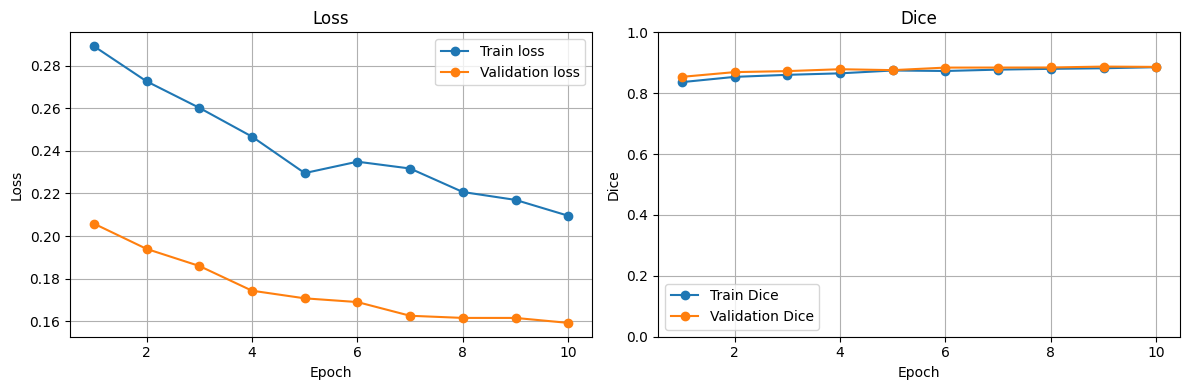

Best epoch: 9
Best validation Dice: 0.8874761635823929
Best validation loss: 0.16147878836709506


In [32]:
epochs = 10

train_losses = []
train_dices = []
val_losses = []
val_dices = []


for epoch in range(epochs):
    train_loss, train_dice = train_one_epoch(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, val_dice = evaluate(val_dataloader, model, loss_fn, device)

    train_losses.append(train_loss)
    train_dices.append(train_dice)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    # Clear the previous epoch display before showing current results.
    clear_output(wait=True)

    # save the model with the best dice and loss
    dice_improved = val_dice > best_val_dice + min_delta

    dice_tied = abs(val_dice - best_val_dice) <= min_delta
    loss_improved = val_loss < best_val_loss

    if dice_improved or (dice_tied and loss_improved):
        best_val_dice = val_dice
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "val_dice": best_val_dice,
            },
            checkpoint_path,
        )

        print(
            f"Saved best model at epoch {best_epoch}: "
            f"val Dice={best_val_dice:.4f}, "
            f"val loss={best_val_loss:.4f}"
        )



    epoch_range = range(1, epoch + 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epoch_range, train_losses, marker="o", label="Train loss")
    axes[0].plot(epoch_range, val_losses, marker="o", label="Validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epoch_range, train_dices, marker="o", label="Train Dice")
    axes[1].plot(epoch_range, val_dices, marker="o", label="Validation Dice")
    axes[1].set_title("Dice")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    print("Best epoch:", best_epoch)
    print("Best validation Dice:", best_val_dice)
    print("Best validation loss:", best_val_loss)

In [33]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Loaded best epoch:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"])
print("Validation loss:", checkpoint["val_loss"])

Loaded best epoch: 9
Validation Dice: 0.8874761635823929
Validation loss: 0.16147878836709506


In [39]:
id_test_loss, id_test_dice = evaluate(id_test_dataloader, model, loss_fn, device)

print(f"Model B: \nId Test loss: {id_test_loss:.4f} \nId Test Dice: {id_test_dice:.4f}")

Model B: 
Id Test loss: 0.2116 
Id Test Dice: 0.8805


In [40]:
ood_test_loss, ood_test_dice = evaluate(ood_test_dataloader, model, loss_fn, device)

print(f"Model B: \nOod Test loss: {ood_test_loss:.4f} \nOod Test Dice: {ood_test_dice:.4f}")

Model B: 
Ood Test loss: 0.5322 
Ood Test Dice: 0.8068


We need to compare its performance with baseline A on odd test set.

In [38]:
baseline_a_model = UNet(n_class=2).to(device)

baseline_a_checkpoint = torch.load(
    "best_baseline_a.pt",
    map_location=device,
    weights_only=True,
)

baseline_a_model.load_state_dict(baseline_a_checkpoint["model_state_dict"])

baseline_a_colon_loss, baseline_a_colon_dice = evaluate(ood_test_dataloader, baseline_a_model, loss_fn, device)

print(f"Baseline A: \nOod Test loss: {baseline_a_colon_loss:.4f} \nOod Test Dice: {baseline_a_colon_dice:.4f}")

Baseline A: 
Ood Test loss: 0.2409 
Ood Test Dice: 0.8384


Model B is trained without Colon.  
It retained strong performance on in-distribution test tissues, achieving a Dice score of 0.8805 and a BCE loss of 0.2116. However, performance decreased on the unseen Colon tissue, where the model achieved a Dice score of 0.8068 and a loss of 0.5322. Dice score decreased by 8.4%.  

To separate the effect of tissue exclusion from the intrinsic difficulty of Colon images, baseline A was evaluated on the same 228 Colon test images (ood test). Dice decreased by 3.8% (0.8384->0.8068)

These results indicate that the U-Net exhibits partial cross-tissue generalization: it can still produce reasonably accurate segmentations on an unseen tissue, but its performance and reliability degrade under tissue-level domain shift. The substantially larger increase in BCE loss than the reduction in thresholded Dice also suggests that the model’s probabilistic outputs are more strongly affected than its final binary overlap.

However, this conclusion is currently limited to one held-out tissue, one random seed, and a combined cell-and-nucleus Dice score. Additional held-out tissues, repeated runs, and channel-specific metrics are required before making a general claim about cross-tissue generalization.